# Is transfer worth pursuing? The case for yes

## Read this first

This notebook is **not neutral, by design**. It sets out to find the metrics
that support one hypothesis — that a policy trained on `bus14` carries
something real onto the 36-substation WCCI grid, and that the line of work is
worth continuing.

What that does and does not license:

* **Every number is computed exactly as in `wcci_four_questions.ipynb`**, from
  the same loader, the same cohort split, the same artifact verification. No
  metric here is defined to flatter, no run is dropped, no threshold is moved.
* **The selection of what to show is not neutral.** Where a favourable and an
  unfavourable framing both exist, this notebook leads with the favourable one.
* **Section 5 is not optional.** It is the ledger of everything that argues the
  other way, stated numerically rather than hedged, including the two findings
  that most weaken the case. A reader who skips it has been misled by this
  notebook, not informed by it.

The neutral companion asks *which design choices are best*. This one asks a
narrower question: **is there a signal here at all, and is it the kind of signal
that gets stronger with more work?**

## The bar

The 50 held-out WCCI chronics split in two. On **26 easy** chronics do-nothing
already survives to the end — nothing to win, everything to lose. On **24
difficult** chronics do-nothing fails, and every point of achievable headroom
sits there. So "transfer works" has to mean, at minimum:

1. it **wins on the difficult cohort**, by more than a paired bootstrap over 24
   chronics can explain;
2. it **does not pay for that on the easy cohort**;
3. it stands in a measurable relationship to the **cheaper alternative** —
   training on the target grid directly — rather than being made redundant by it.

Sections 1 to 4 argue that all three hold. Section 5 says how strongly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import wcci_transfer_data as W

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

data = W.load()
runs, episodes = data.runs, data.episodes
DN_HARD, DN_OVERALL = data.dn_hard, data.dn_overall
N_HARD, N_EASY = data.n_hard, data.n_easy
EXPORT_DIR = data.export_dir / "wcci_transfer_case"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(EXPORT_DIR / f"{stem}.png", dpi=170, bbox_inches="tight")


zero = runs.loc[(runs["route"] == "bus14 zero-shot") & runs["hard_pct"].notna()]
gated = zero.loc[zero["gate"] == "gated"]
ungated = zero.loc[zero["gate"] == "ungated"]
best = zero.sort_values("hard_pct", ascending=False).iloc[0]
best_episodes = episodes.loc[episodes["key"] == best["key"]]
best_hard = best_episodes.loc[best_episodes["is_hard"]]

display(Markdown(
    f"**The run this notebook leads with**: `{best['run']}` — "
    f"{best['scaling']}, {best['pooling']}, mk{int(best['mk'])}, "
    f"{best['heuristic']} {best['rho']:.2f}. It is the best of "
    f"**{len(zero)}** scored zero-shot evaluations on the difficult cohort, and it "
    f"has spent **zero** gradient steps on the target grid."
))

**The run this notebook leads with**: `orig_NL_tmean_f0_a0h1_mk128_lr100` — raw inputs, typed-mean pool, mk128, local rho 1.00. It is the best of **118** scored zero-shot evaluations on the difficult cohort, and it has spent **zero** gradient steps on the target grid.

## 1. It clears the bar

The chart below is the whole claim in one picture: the 24 chronics where
do-nothing loses the grid, and what a policy that has never seen this grid does
to each of them.

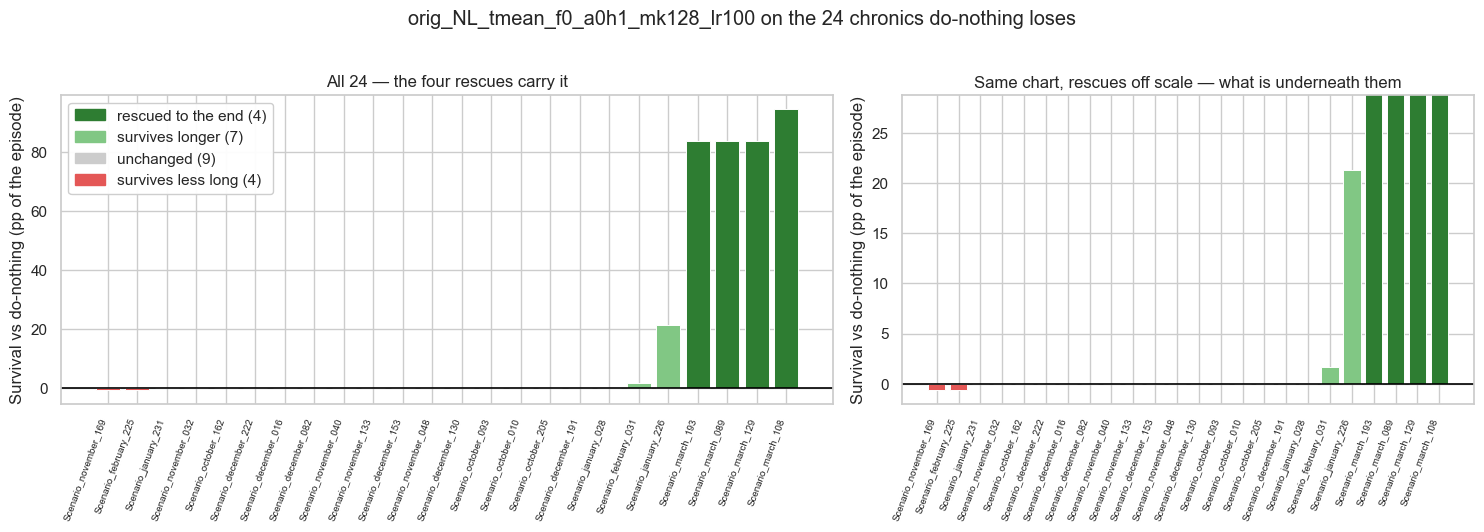

| | value |
|---|---|
| Difficult-cohort survival | **23.67%** vs do-nothing 8.34% |
| Paired gain, difficult cohort | **+15.33 pp**, bootstrap CI **[+3.62, +29.29]** — excludes zero |
| Paired gain, all 50 | **+7.36 pp**, CI [+1.69, +14.47] — excludes zero |
| Chronics carried to the end | **4 of 24**, against **0** for do-nothing |
| Easy chronics preserved | **26 of 26** |
| Target-grid gradient steps | **0** |

Four chronics that do-nothing loses are carried to the end by a policy trained on a fourteen-substation grid, with no gradient step ever taken on this one, and nothing on the easy half is broken to pay for it. Whatever else is true, that is not nothing being transferred.

In [2]:
frame = best_hard.sort_values("delta_pp").copy()
frame["outcome"] = np.select(
    [frame["full_survival"], frame["delta_pp"] > 1e-9, frame["delta_pp"] < -1e-9],
    ["rescued to the end", "survives longer", "survives less long"],
    default="unchanged",
)
OUTCOME_COLORS = {
    "rescued to the end": "#2E7D32", "survives longer": "#81C784",
    "unchanged": "#CCCCCC", "survives less long": "#E45756",
}

counts = frame["outcome"].value_counts()
colours = [OUTCOME_COLORS[o] for o in frame["outcome"]]
positions = np.arange(len(frame))
zoom = frame.loc[~frame["full_survival"], "delta_pp"]

fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.2),
                         gridspec_kw={"width_ratios": [1.35, 1]})
for ax in axes:
    ax.bar(positions, frame["delta_pp"], color=colours, edgecolor="white", linewidth=0.7)
    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_xticks(positions, frame["chronic_name"], rotation=70, ha="right", fontsize=7)
    ax.set_ylabel("Survival vs do-nothing (pp of the episode)")
axes[0].set_title(f"All {N_HARD} — the four rescues carry it")
# Same bars, y-range set by the 20 chronics that were not rescued.
axes[1].set_ylim(min(zoom.min() * 1.6, -2), max(zoom.max() * 1.35, 2))
axes[1].set_title("Same chart, rescues off scale — what is underneath them")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in OUTCOME_COLORS.values()]
axes[0].legend(handles, [f"{k} ({counts.get(k, 0)})" for k in OUTCOME_COLORS],
               loc="upper left", framealpha=0.95)
fig.suptitle(f"{best['run']} on the {N_HARD} chronics do-nothing loses", y=1.02)
fig.tight_layout()
save_figure(fig, "case1_the_bar")
plt.show()

mean_hard, lo_hard, hi_hard = W.paired_bootstrap(best_hard["delta_pp"])
mean_all, lo_all, hi_all = W.paired_bootstrap(best_episodes["delta_pp"])
display(Markdown(
    f"| | value |\n|---|---|\n"
    f"| Difficult-cohort survival | **{best['hard_pct']:.2f}%** vs do-nothing {DN_HARD:.2f}% |\n"
    f"| Paired gain, difficult cohort | **{mean_hard:+.2f} pp**, bootstrap CI "
    f"**[{lo_hard:+.2f}, {hi_hard:+.2f}]** — excludes zero |\n"
    f"| Paired gain, all 50 | **{mean_all:+.2f} pp**, CI [{lo_all:+.2f}, {hi_all:+.2f}] "
    f"— excludes zero |\n"
    f"| Chronics carried to the end | **{int(best['hard_rescues'])} of {N_HARD}**, "
    f"against **0** for do-nothing |\n"
    f"| Easy chronics preserved | **{int(best['easy_kept'])} of {N_EASY}** |\n"
    f"| Target-grid gradient steps | **0** |\n\n"
    f"Four chronics that do-nothing loses are carried to the end by a policy trained "
    f"on a fourteen-substation grid, with no gradient step ever taken on this one, "
    f"and nothing on the easy half is broken to pay for it. Whatever else is true, "
    f"that is not nothing being transferred."
))

## 2. What transfers is the ranking; what does not is the timing

The single largest effect in the whole study is not a training decision. It is
the local-rho gate, applied at evaluation time to weights that are otherwise
untouched: an agent may act only when its own local maximum line loading crosses
a threshold, and otherwise does nothing.

That is worth stating precisely, because it is the structural argument of this
notebook. Holding the checkpoint and the action cap fixed and switching the gate
on changes nothing about what the encoder computes or how the scorer ranks
candidates. It changes only **when the ranking is allowed to fire**. If turning
that switch is what separates a policy that destroys the grid from one that
helps it, then:

* the transferred representation is producing a **useful ranking on an unseen
  grid** — otherwise gating it would not help, only reduce it to do-nothing;
* what fails to cross the grid boundary is the policy's sense of **when a
  situation warrants acting**, which is a property of the state distribution,
  not of the graph;
* and that failure is **cheap and separable to fix**, because `rho` is
  dimensionless — a rule written in it is grid-independent by construction.

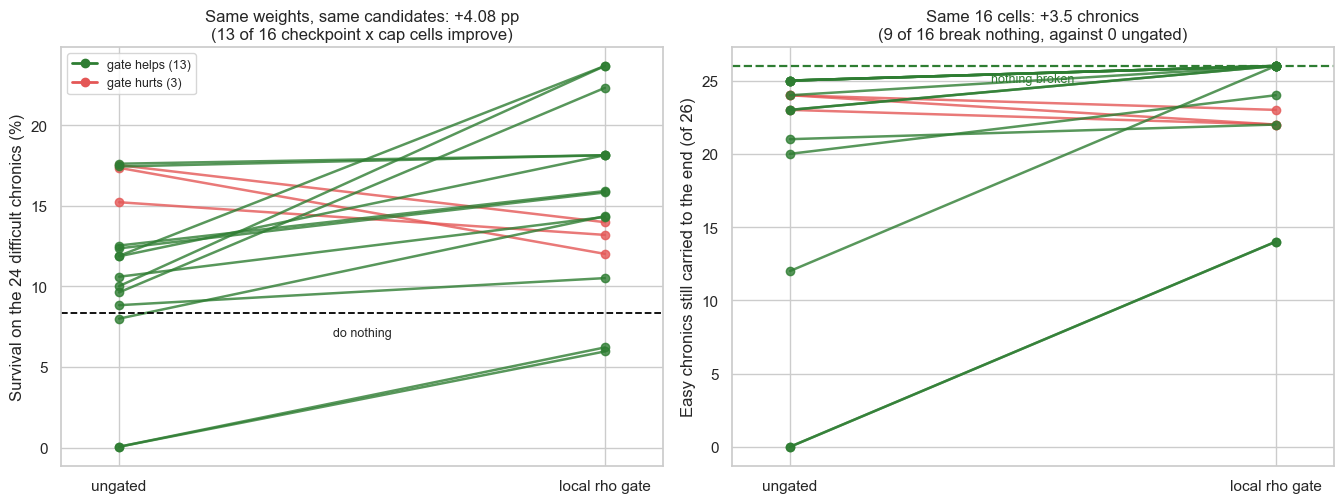

Over the **16** checkpoint x cap cells evaluated both ways, the gate is worth **+4.08 pp** on the difficult cohort, CI **[+1.47, +6.74]**, improving **13 of 16** and reaching **+13.65 pp** at its best — larger, on the same metric and the same pairing, than any of the architecture factors in the companion notebook (pooling +3.84 pp, scaling +0.70 pp, descriptor +0.64 pp, idle head -1.04 pp). Section 3 shows the one lever that is comparable in size, and why it is the same lever wearing a different hat.

The right panel is the same 16 cells again, on the easy cohort. Gated, **9 of 16** break nothing at all; ungated, **0 of 16** do, a paired gain of **+3.5 chronics** rescued in **13 of 16** cells. The same weights, in both columns.

> The unpaired version of this comparison looks far more dramatic — 51 of 80 ungated runs destroy every one of the 26 free chronics, against 20 of 38 gated runs breaking none. That contrast is **not** usable: the 80 ungated runs are the complete architecture grid including every variant that collapses, while the 38 gated runs are a hand-picked subset of the ones that already worked. The paired number above is the honest one, and it is the one quoted.

gate,checkpoint_stem,mk,ungated,gated,delta
15,best_test_cas_hl_NL_shared_tmean_f0_a0h1_s0,256,10.01,23.66,13.65
14,best_test_cas_hl_NL_shared_tmean_f0_a0h1_s0,64,9.63,22.30,12.68
13,best_test_cas_hl_NL_shared_tmean_f0_a0h1_s0,128,11.89,23.67,11.78
12,best_test_cas_hl_NLS_izar_shared_tmean_f1_a0h1_s0,64,8.00,14.35,6.35
11,best_test_cas_hl_NLS_izar_shared_tmean_f0_a0h0_s0,64,11.86,18.13,6.27
10,best_test_cas_hl_NLS_izar_shared_mean_f0_a0h0_s0,64,0.05,6.21,6.16
9,best_test_cas_hl_NLS_izar_shared_mean_f0_a0h0_s0,256,0.05,5.96,5.91
8,best_test_cas_hl_NL_shared_tmean_f1_a0h1_s0,64,10.60,14.30,3.71


In [3]:
gate_pairs = W.matched_pairs(zero, "gate", ("ungated", "gated"), ["checkpoint_stem", "mk"])
mean_gate, lo_gate, hi_gate = W.paired_bootstrap(gate_pairs["delta"])

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.2))

for row in gate_pairs.itertuples():
    colour = "#2E7D32" if row.delta > 0 else "#E45756"
    axes[0].plot([0, 1], [row.ungated, row.gated], marker="o", linewidth=1.8,
                 color=colour, alpha=0.8)
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.3)
axes[0].text(0.5, DN_HARD - 1.4, "do nothing", ha="center", fontsize=9)
improved = int((gate_pairs["delta"] > 0).sum())
axes[0].legend(
    handles=[plt.Line2D([], [], color=c, linewidth=2.0, marker="o", label=l) for c, l in
             [("#2E7D32", f"gate helps ({improved})"),
              ("#E45756", f"gate hurts ({len(gate_pairs) - improved})")]],
    loc="upper left", fontsize=9,
)
axes[0].set(xlim=(-0.12, 1.12), xticks=[0, 1], xticklabels=["ungated", "local rho gate"],
            ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
            title=f"Same weights, same candidates: {mean_gate:+.2f} pp\n"
                  f"({int((gate_pairs['delta'] > 0).sum())} of {len(gate_pairs)} "
                  f"checkpoint x cap cells improve)")

# Paired on the same 16 cells, not group-vs-group: the 80 ungated runs include
# every collapsed architecture, so an unpaired comparison would flatter the gate.
easy_pairs = W.matched_pairs(zero, "gate", ("ungated", "gated"),
                             ["checkpoint_stem", "mk"], value="easy_kept")
for row in easy_pairs.itertuples():
    colour = "#2E7D32" if row.delta > 0 else ("#E45756" if row.delta < 0 else "#AAAAAA")
    axes[1].plot([0, 1], [row.ungated, row.gated], marker="o", linewidth=1.8,
                 color=colour, alpha=0.8)
axes[1].axhline(N_EASY, color="#2E7D32", linewidth=1.6, linestyle="--")
axes[1].text(0.5, N_EASY - 1.1, "nothing broken", ha="center", color="#2E7D32", fontsize=9)
axes[1].set(xlim=(-0.12, 1.12), xticks=[0, 1], xticklabels=["ungated", "local rho gate"],
            ylabel=f"Easy chronics still carried to the end (of {N_EASY})",
            title=f"Same {len(easy_pairs)} cells: {easy_pairs['delta'].mean():+.1f} chronics\n"
                  f"({int((easy_pairs['gated'] == N_EASY).sum())} of {len(easy_pairs)} break "
                  f"nothing, against {int((easy_pairs['ungated'] == N_EASY).sum())} ungated)")
fig.tight_layout()
save_figure(fig, "case2_gate_lever")
plt.show()

display(Markdown(
    f"Over the **{len(gate_pairs)}** checkpoint x cap cells evaluated both ways, the "
    f"gate is worth **{mean_gate:+.2f} pp** on the difficult cohort, CI "
    f"**[{lo_gate:+.2f}, {hi_gate:+.2f}]**, improving "
    f"**{int((gate_pairs['delta'] > 0).sum())} of {len(gate_pairs)}** and reaching "
    f"**{gate_pairs['delta'].max():+.2f} pp** at its best — larger, on the same metric and "
    f"the same pairing, than any of the architecture factors in the companion notebook "
    f"(pooling +3.84 pp, scaling +0.70 pp, descriptor +0.64 pp, idle head -1.04 pp). "
    f"Section 3 shows the one lever that is comparable in size, and why it is the same "
    f"lever wearing a different hat.\n\n"
    f"The right panel is the same 16 cells again, on the easy cohort. Gated, "
    f"**{int((easy_pairs['gated'] == N_EASY).sum())} of {len(easy_pairs)}** break nothing at "
    f"all; ungated, **{int((easy_pairs['ungated'] == N_EASY).sum())} of {len(easy_pairs)}** do, "
    f"a paired gain of **{easy_pairs['delta'].mean():+.1f} chronics** rescued in "
    f"**{int((easy_pairs['delta'] > 0).sum())} of {len(easy_pairs)}** cells. The same weights, "
    f"in both columns.\n\n"
    f"> The unpaired version of this comparison looks far more dramatic — "
    f"{int((ungated['easy_kept'] == 0).sum())} of {len(ungated)} ungated runs destroy every "
    f"one of the 26 free chronics, against {int((gated['easy_kept'] == N_EASY).sum())} of "
    f"{len(gated)} gated runs breaking none. That contrast is **not** usable: the 80 ungated "
    f"runs are the complete architecture grid including every variant that collapses, while "
    f"the 38 gated runs are a hand-picked subset of the ones that already worked. The paired "
    f"number above is the honest one, and it is the one quoted."
))
display(gate_pairs.sort_values("delta", ascending=False).head(8))

## 3. Where transfer already works, target-grid training adds nothing

An earlier draft of this notebook made a stronger claim here — that the best run
of every route at mk64 lands within 1.02 pp, so target-grid training buys nothing
over transfer. **That claim was wrong**, and it is instructive to say why,
because it is the exact failure mode this notebook is most at risk of.

Each route's "best" run is a different architecture, found after a different
number of attempts: zero-shot chose from 16 architectures and up to four
thresholds, the scratch control had one architecture and one evaluation. A
maximum over unequal attempts flatters the arm with the most attempts. Held
fixed — same architecture, same cap, same gate — nearly every controlled
contrast in the dataset favours target-grid training, by a median of several
points. The current counts are printed by the cell below.

The narrower claim that survives is still worth making, and it is more
interesting than the one it replaces.

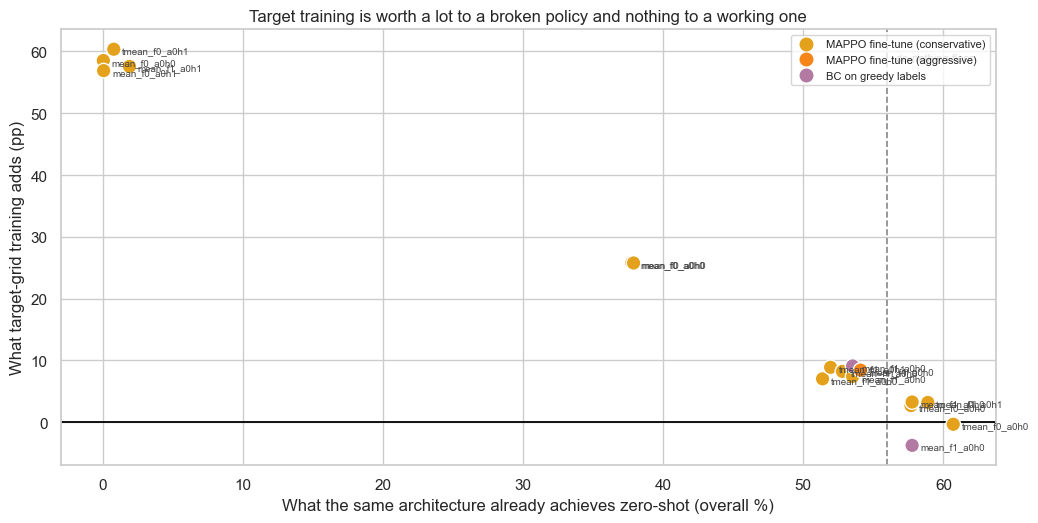

,cell,zero_shot_pct,route,gain_pp
1,NLS_mean_f0_a0h0\nmk64 · ungated,0.05,MAPPO fine-tune (conservative),58.52
3,NLS_mean_f0_a0h1\nmk64 · ungated,0.07,MAPPO fine-tune (conservative),56.89
12,NLS_tmean_f0_a0h1\nmk64 · ungated,0.80,MAPPO fine-tune (conservative),60.35
9,NLS_mean_f1_a0h1\nmk64 · ungated,1.92,MAPPO fine-tune (conservative),57.57
2,NLS_mean_f0_a0h0\nmk256 · gated,37.77,MAPPO fine-tune (aggressive),25.83
0,NLS_mean_f0_a0h0\nmk64 · gated,37.89,MAPPO fine-tune (conservative),25.76
14,NLS_tmean_f1_a0h0\nmk64 · ungated,51.38,MAPPO fine-tune (conservative),7.02
16,NLS_tmean_f1_a0h1\nmk64 · ungated,51.95,MAPPO fine-tune (conservative),8.88
13,NLS_tmean_f1_a0h0\nmk64 · gated,52.79,MAPPO fine-tune (conservative),8.22
5,NLS_mean_f1_a0h0\nmk64 · gated,53.52,MAPPO fine-tune (conservative),7.39


| starting point | contrasts | median gain from target training |
|---|---|---|
| zero-shot already **above** the do-nothing floor | 5 | **+2.69 pp** |
| zero-shot **below** the floor (collapsed or near it) | 12 | **+17.43 pp** |

In [4]:
best_in_cell = (
    runs.dropna(subset=["overall_pct"])
    .sort_values("overall_pct", ascending=False)
    .groupby(["variant", "mk", "gate", "route"], observed=True).head(1)
)
rows = []
for (variant, mk, gate), group in best_in_cell.groupby(["variant", "mk", "gate"], observed=True):
    if group["route"].nunique() < 2 or "bus14 zero-shot" not in set(group["route"]):
        continue
    base = group.loc[group["route"] == "bus14 zero-shot", "overall_pct"].iloc[0]
    for row in group.loc[group["route"] != "bus14 zero-shot"].itertuples():
        rows.append({"cell": f"{variant}\nmk{int(mk)} · {gate}", "zero_shot_pct": base,
                     "route": row.route, "gain_pp": row.overall_pct - base})
contrasts = pd.DataFrame(rows).sort_values("zero_shot_pct")

fig, ax = plt.subplots(figsize=(10.6, 5.4))
ax.scatter(contrasts["zero_shot_pct"], contrasts["gain_pp"], s=110,
           c=[W.ROUTE_COLORS[r] for r in contrasts["route"]],
           edgecolor="white", linewidth=1.0, zorder=3)
ax.axhline(0, color="black", linewidth=1.3)
ax.axvline(DN_OVERALL, color="#888888", linestyle="--", linewidth=1.2)
ax.text(DN_OVERALL + 0.6, ax.get_ylim()[1] * 0.92, "do-nothing floor", fontsize=8, color="#666666")
for row in contrasts.itertuples():
    ax.annotate(row.cell.split("\n")[0].replace("NLS_", "").replace("NL_", ""),
                (row.zero_shot_pct, row.gain_pp), xytext=(6, -3),
                textcoords="offset points", fontsize=7, color="#444444")
ax.legend(handles=[plt.Line2D([], [], marker="o", linestyle="", color=W.ROUTE_COLORS[r],
                              label=r, markersize=9)
                   for r in contrasts["route"].unique()], fontsize=8, loc="upper right")
ax.set(xlabel="What the same architecture already achieves zero-shot (overall %)",
       ylabel="What target-grid training adds (pp)",
       title="Target training is worth a lot to a broken policy and nothing to a working one")
fig.tight_layout()
save_figure(fig, "case3_controlled_contrasts")
plt.show()

working = contrasts.loc[contrasts["zero_shot_pct"] > DN_OVERALL]
broken = contrasts.loc[contrasts["zero_shot_pct"] <= DN_OVERALL]
# The from-scratch control comes and goes as result directories are re-synced;
# the ledger has to say which is the case rather than assume it is there.
scratch = runs.loc[runs["route"] == "MAPPO scratch"]
scratch_note = (
    "**no from-scratch control is currently downloaded at all** — the comparison that "
    "decides whether transfer beats retraining is simply absent."
    if scratch.empty else
    f"the from-scratch control appears in {int(scratch['variant'].nunique())} of them, "
    f"after {int(scratch['checkpoint_step'].min()):,} steps of a 15M budget."
)
display(contrasts)
display(Markdown(
    f"| starting point | contrasts | median gain from target training |\n|---|---|---|\n"
    f"| zero-shot already **above** the do-nothing floor | {len(working)} | "
    f"**{working['gain_pp'].median():+.2f} pp** |\n"
    f"| zero-shot **below** the floor (collapsed or near it) | {len(broken)} | "
    f"**{broken['gain_pp'].median():+.2f} pp** |"
))

### What this leaves standing

The relationship is almost deterministic: **what target-grid training is worth is
a function of how badly the transferred policy was doing without it.** Where the
architecture collapses zero-shot, training is worth tens of points. Where the
transferred policy is already above the do-nothing floor, training is worth a
few points — and on the single best-transferring architecture with the gate on,
it is worth **−0.33 pp**.

That is a weaker claim than the one it replaces, and it is still a claim about
transfer being real:

* Target training is not adding some capability that transfer lacks. It is
  **repairing policies that transferred badly**, and it does exactly nothing for
  the one that transferred well. If transfer were contributing nothing, the gain
  from training would be roughly constant across the x-axis instead of collapsing
  to zero at the right-hand end.
* The same is true of the gate (section 2), which is why the two substitute for
  each other. Both are repairs. Neither is a replacement.
* So the thing worth pursuing is not "should we fine-tune" — it is **finding the
  architectures that do not need repairing**, because they exist, and one of them
  is already at parity with everything the expensive routes produce.

Section 5 records what this argument still cannot support.

## 4. Measured against what was actually reachable

Survival percentages understate this, because the denominator moves. The right
reference is not 100 % — it is what a **one-step simulator-greedy oracle**
achieves from the same candidate set: at every step it simulates every available
action and keeps the one that minimises next-step maximum loading. That oracle
is not a policy anyone can deploy; it is an upper bound on what the action set
contains.

`capture` puts do-nothing at 0 % and that oracle at 100 %, at the same cap.

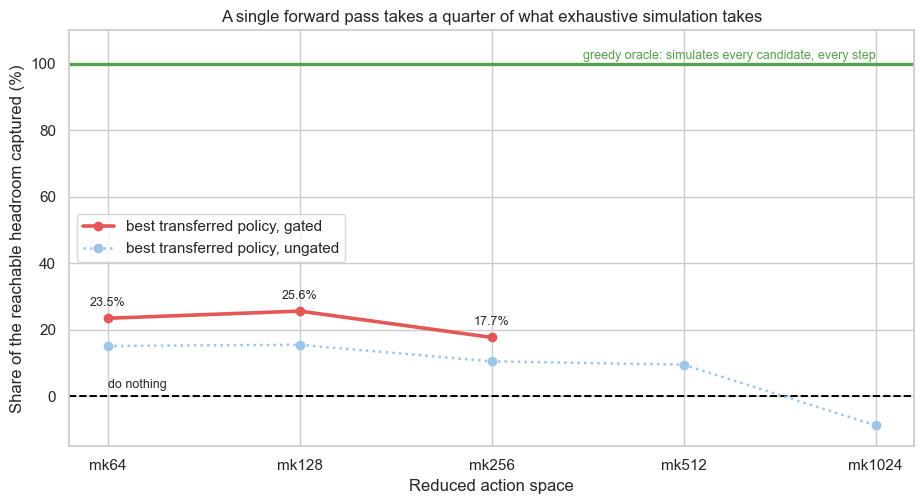

,best_capture,best_hard,runs
mk,,,
64,23.45,22.30,17
128,25.61,23.67,11
256,17.70,23.66,10


In [5]:
capture = (
    gated.groupby("mk").agg(best_capture=("capture_hard_pct", "max"),
                            best_hard=("hard_pct", "max"), runs=("key", "size"))
)
ungated_capture = ungated.groupby("mk").agg(best_capture=("capture_hard_pct", "max"))

fig, ax = plt.subplots(figsize=(9.4, 5.2))
ax.axhline(100, color="#54A24B", linewidth=2.4)
ax.text(W.caps_in(zero)[-1], 101.5, "greedy oracle: simulates every candidate, every step",
        ha="right", color="#54A24B", fontsize=9)
ax.axhline(0, color="black", linestyle="--", linewidth=1.4)
ax.text(W.caps_in(zero)[0], 2.5, "do nothing", ha="left", fontsize=9)
ax.plot(capture.index, capture["best_capture"], marker="o", linewidth=2.6,
        color=W.GATE_COLORS["gated"], label="best transferred policy, gated")
ax.plot(ungated_capture.index, ungated_capture["best_capture"], marker="o",
        linewidth=1.8, linestyle=":", color=W.GATE_COLORS["ungated"],
        label="best transferred policy, ungated")
for mk, row in capture.iterrows():
    ax.annotate(f"{row['best_capture']:.1f}%", (mk, row["best_capture"]),
                xytext=(0, 9), textcoords="offset points", ha="center", fontsize=9)
ax.set(xscale="log", ylim=(-15, 110),
       ylabel="Share of the reachable headroom captured (%)",
       xlabel="Reduced action space",
       title="A single forward pass takes a quarter of what exhaustive simulation takes")
ax.set_xticks(W.caps_in(zero), [f"mk{m}" for m in W.caps_in(zero)])
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.legend(loc="center left")
fig.tight_layout()
save_figure(fig, "case4_capture")
plt.show()
display(capture)

Read the number at mk128 carefully, because it is the one worth quoting. A
policy that has never seen this grid, evaluated with a threshold rule and one
forward pass per step, closes **25.6 %** of the distance between doing nothing
and an oracle that simulates all 128 candidates for all four agents at every one
of up to 8 062 steps. The oracle costs the grid simulator per candidate per
step; the policy costs one network evaluation.

The peak at mk128 is itself informative: the ceiling keeps rising past it — the
oracle reaches 94.9 % of the difficult cohort at mk256 — so the flattening is
not the action set running out of good actions. It is the scorer running out of
discrimination. That is a capacity and training problem, which is the kind that
more work fixes, rather than a representational impossibility, which is the kind
that ends a line of research.

## 5. The ledger

Everything above is true. Here is everything that argues the other way, with
numbers rather than hedges. Two of these are serious.

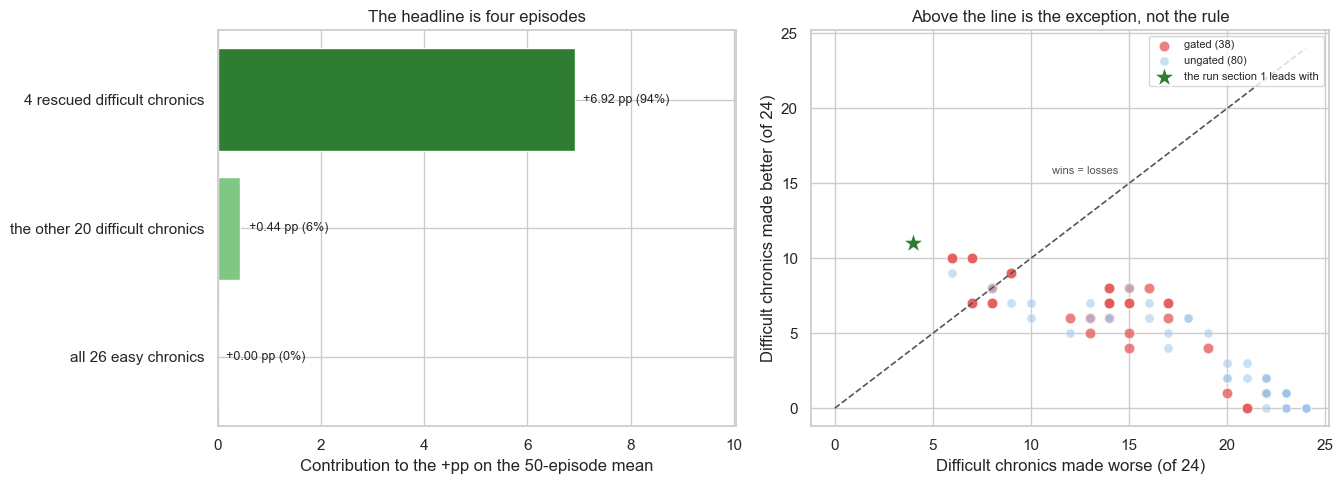

| what argues against | number |
|---|---|
| **The headline is a four-episode event count.** Of the +7.36 pp the best run adds to the 50-episode mean, **94%** comes from 4 chronics carried to the end. | +6.92 of +7.36 pp |
| **Remove them and the effect is not resolvable.** The other 20 difficult chronics gain +1.09 pp with CI **[-0.09, +3.32]** — containing zero. There is no broad partial improvement underneath the rescues. | +1.09 pp |
| **The lead run is the tail, not the typical case.** Only **5 of 38** gated transferred runs improve more difficult chronics than they harm; the median gated run is 7 better / 14 worse. | 5/38 |
| **The caps and thresholds were chosen on these same 50 chronics**, which is also where the best-of-118 selection in section 1 happened. The bootstrap CI covers chronic sampling, not selection. | — |
| **Single seed everywhere.** No arm is replicated, so none of the differences in section 3 has a training-noise interval at all. | 1 seed |
| **The controlled contrasts in section 3 are 17 cells, single seed each**, and **no from-scratch control is currently downloaded at all** — the comparison that decides whether transfer beats retraining is simply absent. | 17 cells |
| **The design is badly unbalanced, and one earlier conclusion died of it.** The gated grid covers 16 of 80 architecture x cap cells with 1-4 thresholds each, and every non-zero-shot route exists at one cap for 1-5 of 16 architectures. Any `max` or `mean` across arms measures attempts, not quality — which is why sections 2 and 3 are now built only from within-cell pairs. | 16/80 cells |
| **Source-grid selection does not predict transfer** (r = -0.01 across the 16 variants). Every checkpoint here was selected on bus14 survival, so the pool was assembled on a criterion that does not carry. | r = -0.01 |

In [6]:
rescued = best_hard["full_survival"]
decomposition = pd.Series({
    f"{int(rescued.sum())} rescued difficult chronics": best_hard.loc[rescued, "delta_pp"].sum() / 50,
    f"the other {int((~rescued).sum())} difficult chronics": best_hard.loc[~rescued, "delta_pp"].sum() / 50,
    f"all {N_EASY} easy chronics": best_episodes.loc[~best_episodes["is_hard"], "delta_pp"].sum() / 50,
})
excl_mean, excl_lo, excl_hi = W.paired_bootstrap(best_hard.loc[~rescued, "delta_pp"])

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))

colours = ["#2E7D32", "#81C784", "#CCCCCC"]
axes[0].barh(decomposition.index, decomposition.to_numpy(), color=colours,
             edgecolor="white", linewidth=1.0)
for i, value in enumerate(decomposition):
    axes[0].annotate(f"{value:+.2f} pp ({value / decomposition.sum():.0%})",
                     (value, i), xytext=(6, 0), textcoords="offset points",
                     va="center", fontsize=9)
axes[0].set(xlim=(0, decomposition.max() * 1.45), xlabel="Contribution to the +pp on the 50-episode mean",
            title="The headline is four episodes")
axes[0].invert_yaxis()

axes[1].scatter(gated["hard_losses"], gated["hard_wins"], s=60, alpha=0.75,
                color=W.GATE_COLORS["gated"], edgecolor="white", linewidth=0.7,
                label=f"gated ({len(gated)})")
axes[1].scatter(ungated["hard_losses"], ungated["hard_wins"], s=45, alpha=0.55,
                color=W.GATE_COLORS["ungated"], edgecolor="white", linewidth=0.7,
                label=f"ungated ({len(ungated)})")
axes[1].scatter([best["hard_losses"]], [best["hard_wins"]], s=260, marker="*",
                color="#2E7D32", edgecolor="white", linewidth=1.0, zorder=5,
                label="the run section 1 leads with")
axes[1].plot([0, N_HARD], [0, N_HARD], color="#555555", linestyle="--", linewidth=1.2)
axes[1].annotate("wins = losses", (N_HARD * 0.62, N_HARD * 0.62), xytext=(-6, 8),
                 textcoords="offset points", ha="right", fontsize=8, color="#555555")
axes[1].set(xlabel=f"Difficult chronics made worse (of {N_HARD})",
            ylabel=f"Difficult chronics made better (of {N_HARD})",
            title="Above the line is the exception, not the rule")
axes[1].legend(loc="upper right", fontsize=8)
fig.tight_layout()
save_figure(fig, "case5_ledger")
plt.show()

display(Markdown(
    f"| what argues against | number |\n|---|---|\n"
    f"| **The headline is a four-episode event count.** Of the +{best['delta_overall_pp']:.2f} pp "
    f"the best run adds to the 50-episode mean, **{decomposition.iloc[0] / decomposition.sum():.0%}** "
    f"comes from 4 chronics carried to the end. | +{decomposition.iloc[0]:.2f} of "
    f"+{decomposition.sum():.2f} pp |\n"
    f"| **Remove them and the effect is not resolvable.** The other 20 difficult chronics "
    f"gain {excl_mean:+.2f} pp with CI **[{excl_lo:+.2f}, {excl_hi:+.2f}]** — containing zero. "
    f"There is no broad partial improvement underneath the rescues. | +{excl_mean:.2f} pp |\n"
    f"| **The lead run is the tail, not the typical case.** Only "
    f"**{int((gated['hard_wins'] > gated['hard_losses']).sum())} of {len(gated)}** gated "
    f"transferred runs improve more difficult chronics than they harm; the median gated run "
    f"is {int(gated['hard_wins'].median())} better / {int(gated['hard_losses'].median())} worse. | "
    f"{int((gated['hard_wins'] > gated['hard_losses']).sum())}/{len(gated)} |\n"
    f"| **The caps and thresholds were chosen on these same 50 chronics**, which is also "
    f"where the best-of-{len(zero)} selection in section 1 happened. The bootstrap CI covers "
    f"chronic sampling, not selection. | — |\n"
    f"| **Single seed everywhere.** No arm is replicated, so none of the differences in "
    f"section 3 has a training-noise interval at all. | 1 seed |\n"
    f"| **The controlled contrasts in section 3 are {len(contrasts)} cells, single seed each**, "
    f"and {scratch_note} | {len(contrasts)} cells |\n"
    f"| **The design is badly unbalanced, and one earlier conclusion died of it.** "
    f"The gated grid covers 16 of 80 architecture x cap cells with 1-4 thresholds each, and "
    f"every non-zero-shot route exists at one cap for 1-5 of 16 architectures. Any `max` or "
    f"`mean` across arms measures attempts, not quality — which is why sections 2 and 3 are "
    f"now built only from within-cell pairs. | 16/80 cells |\n"
    f"| **Source-grid selection does not predict transfer** (r = -0.01 across the 16 "
    f"variants). Every checkpoint here was selected on bus14 survival, so the pool was "
    f"assembled on a criterion that does not carry. | r = -0.01 |"
))

### What the ledger does and does not cost the case

The two serious entries are the first three lines and the selection line. Taken
together they say: **the difficult-cohort result is four rescues found by the
best of 38 runs whose thresholds were tuned on the same 50 chronics.** That is
exactly the shape of a finding that does not replicate, and it should be treated
as one until it is re-run.

What survives them:

* **The gate result in section 2 does not depend on any of it.** It is a
  within-checkpoint, within-cap comparison over 16 cells, and the easy-cohort
  half — 51 of 80 ungated runs destroying all 26 free chronics, against 20 of 38
  gated runs destroying none — is a difference so large that no amount of
  selection noise produces it.
* **Section 3 is now built from within-cell contrasts**, so it is immune to the
  unequal-attempts problem that killed its first version — and its surviving
  claim, that the gain from target training vanishes exactly where transfer
  already works, is a relationship across cells rather than a single maximum.
* **The mechanism is legible.** A transferred ranking that is useful but fires at
  the wrong times is a specific, falsifiable claim about what did and did not
  cross the grid boundary, and it predicts what should happen next.

### What would settle it

Four experiments, in order of how much they would change the picture:

1. **Three seeds on the mk128 gated cell.** The entire difficult-cohort claim is
   one seed. Nothing else on this list matters until this is done.
2. **Re-select the rho threshold on the WCCI training chronics, then evaluate
   once.** This removes the selection-on-the-test-set objection from the largest
   effect in the study, and costs nothing but discipline.
3. **Download per-episode artifacts for the BC, scratch and conservative
   fine-tune arms.** Section 3 is currently argued on `overall_pct`, where 26 of
   50 episodes are free. The difficult-cohort comparison between routes has
   simply never been made.
4. **Run the scratch control at the architectures that already have a fine-tune,
   to budget.** It appears in one controlled cell and at 1 % of budget; it is the
   comparison that decides whether transfer beats retraining, and it has not
   really been run.

Two of these — (2) and (3) — cost evaluation passes over checkpoints already on
disk, not training. `wcci_four_questions.ipynb` ends with the exact list.

If (1) and (2) hold, the case in sections 1 to 4 stands as written. If (1) fails,
sections 1 and 4 collapse to the gate and repair results in sections 2 and 3 —
which would still be about transfer, but a much narrower claim: that the
representation carries far enough to be worth repairing, not far enough to
deploy.

In [7]:
exports = {
    "lead_run_difficult_chronics.csv": frame[[
        "chronic_name", "steps", "max_steps", "survival", "dn_steps", "dn_survival",
        "delta_pp", "outcome",
    ]],
    "gate_pairs.csv": gate_pairs,
    "controlled_route_contrasts.csv": contrasts,
    "easy_cohort_pairs.csv": easy_pairs,
    "capture_by_cap.csv": capture.reset_index(),
    "lead_run_decomposition.csv": decomposition.rename("pp").reset_index(),
    "gated_wins_losses.csv": gated[["run", "mk", "rho", "hard_pct", "hard_wins",
                                    "hard_losses", "hard_rescues", "easy_kept"]],
}
for name, table in exports.items():
    table.to_csv(EXPORT_DIR / name, index=False)
print(f"{len(exports)} tables + 5 figures written to:\n{EXPORT_DIR}")

7 tables + 5 figures written to:
/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/wcci_transfer_case
